# Notebook 03 — Model Training

**Stage 1 — PD Model:** XGBoost classifier for early default prediction  
**Stage 2 — Return Model:** Ridge + LightGBM regression for loan return prediction  

### Speed optimisations applied

| Bottleneck | Original | Fixed |
|---|---|---|
| XGBoost search | `GridSearchCV` 81 fits | `RandomizedSearchCV` n_iter=8 → 24 fits |
| SMOTE input | Full window ~200K rows | Capped at 30K rows before SMOTE |
| Training rows | Full 200K+ per window | Stratified sample 50K rows |
| XGBoost trees | Fixed 150 trees | `tree_method='hist'` + early stopping |
| Random Forest | n_iter=5 on 400K rows | Removed (overfits badly out-of-sample) |
| Crash recovery | Restart from zero | Checkpoint saved after each window |

**Expected runtime: ~20 minutes total**

---
## Cell 1 — Imports

In [1]:
import sys, os, time, warnings, pickle
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scipy.sparse as sparse          # alias must match sparse.issparse() calls below
import joblib
import matplotlib.pyplot as plt
from pandas.tseries.offsets import DateOffset

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error,
    precision_recall_curve, roc_auc_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMRegressor
from imblearn.over_sampling import SMOTE

from src.preprocessing import NUMERICAL_FEATURES, CATEGORICAL_FEATURES, fit_reference_tables
from src.evaluation import calculate_classification_metrics

os.makedirs('../models', exist_ok=True)
os.makedirs('../models/checkpoints', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
print('Imports OK.')

Imports OK.


---
## Cell 2 — Load data

In [2]:
loan_data = pd.read_parquet('../data/processed/loan_data_features.parquet')
loan_data['issue_d'] = pd.to_datetime(loan_data['issue_d'], errors='coerce')
loan_data = loan_data.sort_values('issue_d').reset_index(drop=True)

available_num = [f for f in NUMERICAL_FEATURES if f in loan_data.columns]
available_cat = [f for f in CATEGORICAL_FEATURES if f in loan_data.columns]

print(f'Loaded: {loan_data.shape}')
print(f'Features: {len(available_num)} numerical + {len(available_cat)} categorical')
print(f'Date range: {loan_data["issue_d"].min().date()} to {loan_data["issue_d"].max().date()}')

Loaded: (933159, 64)
Features: 24 numerical + 6 categorical
Date range: 2008-01-01 to 2016-12-01


---
## Cell 2b — Time-based train / holdout split

Hold out the last ~20 % of `lc_loan.csv` (labeled) for **final evaluation**.
The rolling window runs only on `loan_train`.
`loan_holdout` is touched once at the end of NB03 for real out-of-sample metrics.

`lc_loan_test.csv` has no labels — it is for submission predictions only.

In [3]:
# ── Time-based train / holdout split ─────────────────────────────────────────
# Hold out the last ~20 % of dated data as a labeled final test set.
# The rolling window runs only on loan_train.
# loan_holdout is touched once at the very end for final metrics.

HOLDOUT_DATE = '2016-05-01'

loan_train   = loan_data[loan_data['issue_d'] <  HOLDOUT_DATE].copy()
loan_holdout = loan_data[loan_data['issue_d'] >= HOLDOUT_DATE].copy()

print(f'Training pool : {len(loan_train):,} rows  '
      f'({loan_train["issue_d"].min().date()} → {loan_train["issue_d"].max().date()})')
print(f'Holdout       : {len(loan_holdout):,} rows  '
      f'({loan_holdout["issue_d"].min().date()} → {loan_holdout["issue_d"].max().date()})')
print(f'Holdout default rate: {loan_holdout["early_default"].mean():.2%}')

Training pool : 738,051 rows  (2008-01-01 → 2016-04-01)
Holdout       : 195,108 rows  (2016-05-01 → 2016-12-01)
Holdout default rate: 6.34%


---
## Cell 3 — Helper functions

In [4]:
def make_preprocessor():
    """
    ColumnTransformer that keeps output sparse.
    StandardScaler with_mean=False is REQUIRED — mean-centering
    a sparse matrix would densify it (defeats the purpose).
    Ridge and LightGBM both handle sparse input natively.
    """
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(with_mean=False), available_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), available_cat)
        ]
    )


def clean_feature_names(raw_names):
    """
    Sanitise feature names for XGBoost.
    XGBoost rejects names containing: [ ] < > space , : ' "
    Replace all with underscores, then deduplicate.
    """
    table = str.maketrans(
        {'[': '_', ']': '_', '<': '_', '>': '_',
         ' ': '_', ',': '_', ':': '_', '"': '_', "'": '_'}
    )
    cleaned = [str(n).translate(table) for n in raw_names]
    seen = {}
    deduped = []
    for name in cleaned:
        seen[name] = seen.get(name, 0) + 1
        deduped.append(name if seen[name] == 1 else f'{name}_{seen[name] - 1}')
    return deduped


print('Helper functions defined.')

Helper functions defined.


---
## Cell 4 — Speed controls and hyperparameter grids

In [5]:
# ── Speed controls ────────────────────────────────────────────────────────────
# Reduce TRAIN_SAMPLE and SMOTE_SAMPLE further if still too slow on your machine.
TRAIN_SAMPLE = 50_000    # max rows per training window (None = use all data)
SMOTE_SAMPLE = 30_000    # rows fed into SMOTE (subset of training window)
XGB_N_ITER   = 8         # RandomizedSearchCV iterations for XGBoost
LGB_N_ITER   = 6         # RandomizedSearchCV iterations for LightGBM

# ── Hyperparameter grids ──────────────────────────────────────────────────────
ridge_params = {
    'alpha': [0.1, 0.5, 1, 5, 10, 50, 100]
}

lgb_params = {
    'n_estimators':      [300],
    'learning_rate':     [0.05, 0.1],
    'num_leaves':        [31, 63],
    'max_depth':         [-1, 10],
    'min_child_samples': [20],
    'subsample':         [0.8],
    'colsample_bytree':  [0.8],
    'reg_lambda':        [1, 10],
}

# XGBoost grid search uses n_estimators=100 (fast search).
# Best params then get refit with n_estimators=400 + early stopping.
xgb_search_params = {
    'max_depth':          [3, 5, 7],
    'learning_rate':      [0.05, 0.1, 0.2],
    'subsample':          [0.8, 1.0],
    'colsample_bytree':   [0.8, 1.0],
    'min_child_weight':   [1, 5],
}

print('Config ready.')
print(f'  TRAIN_SAMPLE : {TRAIN_SAMPLE:,}')
print(f'  SMOTE_SAMPLE : {SMOTE_SAMPLE:,}')
print(f'  XGB_N_ITER   : {XGB_N_ITER}')
print(f'  LGB_N_ITER   : {LGB_N_ITER}')

Config ready.
  TRAIN_SAMPLE : 50,000
  SMOTE_SAMPLE : 30,000
  XGB_N_ITER   : 8
  LGB_N_ITER   : 6


---
## Cell 5 — Rolling window loop

In [6]:
window_size = DateOffset(months=36)
test_period  = DateOffset(months=12)
step_size    = DateOffset(months=12)

# Use loan_train only — loan_holdout is reserved for final labeled evaluation
start_date = loan_train['issue_d'].min()
end_date   = loan_train['issue_d'].max()

smote = SMOTE(random_state=42)

regression_results  = []
clf_results_in_xgb  = []
clf_results_out_xgb = []
last_window = {}
window_num  = 0

while start_date + window_size + test_period <= end_date:
    t0        = time.time()
    train_end = start_date + window_size
    test_end  = train_end  + test_period
    chk_path  = f'../models/checkpoints/window_{window_num}.pkl'

    # ── Resume from checkpoint ────────────────────────────────────────────────
    if os.path.exists(chk_path):
        print(f'Window {window_num}: checkpoint found, skipping...')
        with open(chk_path, 'rb') as f:
            chk = pickle.load(f)
        regression_results.append(chk['reg'])
        clf_results_in_xgb.append(chk['clf_in'])
        clf_results_out_xgb.append(chk['clf_out'])
        last_window = chk['last_window']
        start_date += step_size
        window_num += 1
        continue

    # ── Slice window from loan_train ──────────────────────────────────────────
    train = loan_train[(loan_train['issue_d'] >= start_date) & (loan_train['issue_d'] < train_end)]
    test  = loan_train[(loan_train['issue_d'] >= train_end)  & (loan_train['issue_d'] < test_end)]

    if len(train) == 0 or len(test) == 0:
        start_date += step_size
        window_num += 1
        continue

    print(f'\n── Window {window_num} | {start_date.date()} → {train_end.date()} '
          f'| train={len(train):,}  test={len(test):,}')

    # ── Stratified sample to cap training size ────────────────────────────────
    if TRAIN_SAMPLE and len(train) > TRAIN_SAMPLE:
        n_def  = int(train['early_default'].sum())
        n_norm = len(train) - n_def
        k_def  = min(n_def,  int(TRAIN_SAMPLE * n_def  / len(train)))
        k_norm = min(n_norm, TRAIN_SAMPLE - k_def)

        part_def  = train[train['early_default'] == 1].sample(k_def,  random_state=42)
        part_norm = train[train['early_default'] == 0].sample(k_norm, random_state=42)
        train = pd.concat([part_def, part_norm]).sample(frac=1, random_state=42)

        print(f'   Sampled train → {len(train):,} rows '
              f'(default rate: {train["early_default"].mean():.2%})')

    y_ret_tr = train['return'].values
    y_ret_te = test['return'].values
    y_def_tr = train['early_default'].values
    y_def_te = test['early_default'].values

    # ── Fit reference tables on training slice (for NB06 prediction time) ────
    ref_tables = fit_reference_tables(train)

    # ── Preprocess — keep sparse ──────────────────────────────────────────────
    preprocessor = make_preprocessor()
    X_tr_sp = preprocessor.fit_transform(train[available_num + available_cat])
    X_te_sp = preprocessor.transform(test[available_num  + available_cat])

    if not sparse.issparse(X_tr_sp):
        X_tr_sp = sparse.csr_matrix(X_tr_sp)
    if not sparse.issparse(X_te_sp):
        X_te_sp = sparse.csr_matrix(X_te_sp)

    feature_names = clean_feature_names(preprocessor.get_feature_names_out())

    print(f'   Features: {X_tr_sp.shape[1]:,} | '
          f'sparsity: {1 - X_tr_sp.nnz / (X_tr_sp.shape[0] * X_tr_sp.shape[1]):.1%}')

    # ── SMOTE on capped dense subset ──────────────────────────────────────────
    n_smote = min(X_tr_sp.shape[0], SMOTE_SAMPLE)
    if n_smote < X_tr_sp.shape[0]:
        rng = np.random.RandomState(42)
        idx = rng.choice(X_tr_sp.shape[0], n_smote, replace=False)
        Xs_dense = X_tr_sp[idx].toarray()
        ys        = y_def_tr[idx]
    else:
        Xs_dense = X_tr_sp.toarray()
        ys        = y_def_tr

    X_bal, y_bal = smote.fit_resample(Xs_dense, ys)
    print(f'   SMOTE: {n_smote:,} → {len(y_bal):,} balanced rows')

    # ── Ridge — sparse in ─────────────────────────────────────────────────────
    t1 = time.time()
    ridge_rs = RandomizedSearchCV(
        Ridge(),
        ridge_params,
        n_iter=7,
        scoring='neg_mean_squared_error',
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    ridge_rs.fit(X_tr_sp, y_ret_tr)
    ridge_best = ridge_rs.best_estimator_
    print(f'   Ridge {time.time() - t1:.0f}s | alpha={ridge_rs.best_params_["alpha"]}')

    # ── LightGBM removed: consistently negative R² out-of-sample across all
    #    rolling windows — worse than predicting the mean. Ridge (R²≈+0.004)
    #    is the sole return model. ────────────────────────────────────────────

    reg_df = pd.DataFrame({
        'model':   ['Ridge'],
        'r2_in':   [r2_score(y_ret_tr, ridge_best.predict(X_tr_sp))],
        'r2_out':  [r2_score(y_ret_te, ridge_best.predict(X_te_sp))],
        'mse_out': [mean_squared_error(y_ret_te, ridge_best.predict(X_te_sp))],
    })
    regression_results.append(reg_df)

    # ── XGBoost step 1: hyperparameter search ─────────────────────────────────
    t1 = time.time()
    xgb_search = RandomizedSearchCV(
        XGBClassifier(
            n_estimators=100,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
            verbosity=0
        ),
        xgb_search_params,
        n_iter=XGB_N_ITER,
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=1,
    )
    xgb_search.fit(X_bal, y_bal)
    best_p = xgb_search.best_params_
    print(f'   XGB search {time.time() - t1:.0f}s | {best_p}')

    # ── XGBoost step 2: refit with early stopping ─────────────────────────────
    t1 = time.time()
    n_eval   = min(3000, max(500, int(0.1 * len(X_bal))))
    eval_idx = np.random.RandomState(0).choice(len(X_bal), n_eval, replace=False)
    tr_mask  = np.ones(len(X_bal), dtype=bool)
    tr_mask[eval_idx] = False

    xgb_best = XGBClassifier(
        **best_p,
        n_estimators=400,
        eval_metric='logloss',
        early_stopping_rounds=20,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        verbosity=0,
    )
    xgb_best.fit(
        X_bal[tr_mask],   y_bal[tr_mask],
        eval_set=[(X_bal[eval_idx], y_bal[eval_idx])],
        verbose=False,
    )
    print(f'   XGB refit {time.time() - t1:.0f}s | '
          f'best_iteration={xgb_best.best_iteration}')

    # ── XGBoost predictions ───────────────────────────────────────────────────
    X_te_dense = X_te_sp.toarray() if sparse.issparse(X_te_sp) else X_te_sp
    X_tr_dense = X_tr_sp.toarray() if sparse.issparse(X_tr_sp) else X_tr_sp

    y_prob_te = xgb_best.predict_proba(X_te_dense)[:, 1]
    y_prob_tr = xgb_best.predict_proba(X_tr_dense)[:, 1]

    # ── Threshold optimisation ────────────────────────────────────────────────
    prec, rec, thresh = precision_recall_curve(y_def_te, y_prob_te)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
    best_thresh = thresh[np.argmax(f1s)]
    auc_out     = roc_auc_score(y_def_te, y_prob_te)

    clf_in  = pd.DataFrame(
        [calculate_classification_metrics(y_def_tr, y_prob_tr, best_thresh)],
        index=[start_date]
    )
    clf_out = pd.DataFrame(
        [calculate_classification_metrics(y_def_te, y_prob_te, best_thresh)],
        index=[start_date]
    )
    clf_results_in_xgb.append(clf_in)
    clf_results_out_xgb.append(clf_out)

    print(f'   ✓ Window {window_num} | {time.time() - t0:.0f}s total | '
          f'AUC={auc_out:.4f} | threshold={best_thresh:.3f}')

    # ── last_window: store sparse matrices — ~98 % sparsity keeps pkl < 50 MB
    #    (vs ~3.8 GB for dense). NB04/NB05 call .toarray() when needed. ───────
    last_window = {
        'X_tr_t':          X_tr_sp,          # sparse CSR — call .toarray() in NB04
        'X_te_t':          X_te_sp,          # sparse CSR — call .toarray() in NB04
        'y_def_tr':        y_def_tr,
        'y_def_te':        y_def_te,
        'y_ret_tr':        y_ret_tr,
        'y_ret_te':        y_ret_te,
        'y_prob_xgb_tr':   y_prob_tr,
        'y_prob_xgb_te':   y_prob_te,
        'xgb_best':        xgb_best,
        'ridge_best':      ridge_best,
        'best_thresh_xgb': best_thresh,
        'preprocessor':    preprocessor,
        'feature_names':   feature_names,
        'window_start':    start_date,
        'ref_tables':      ref_tables,
    }

    # ── Save checkpoint ────────────────────────────────────────────────────────
    with open(chk_path, 'wb') as f:
        pickle.dump({
            'reg':         reg_df,
            'clf_in':      clf_in,
            'clf_out':     clf_out,
            'last_window': last_window
        }, f)

    start_date += step_size
    window_num += 1

print('\n\nAll windows complete.')


── Window 0 | 2008-01-01 → 2011-01-01 | train=14,162  test=14,053
   Features: 1,300 | sparsity: 97.7%
   SMOTE: 14,162 → 27,072 balanced rows
   Ridge 4s | alpha=100
   XGB search 60s | {'subsample': 0.8, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
   XGB refit 20s | best_iteration=331
   ✓ Window 0 | 85s total | AUC=0.6193 | threshold=0.031

── Window 1 | 2009-01-01 → 2012-01-01 | train=27,117  test=43,342
   Features: 1,379 | sparsity: 97.8%
   SMOTE: 27,117 → 52,032 balanced rows
   Ridge 1s | alpha=100
   XGB search 196s | {'subsample': 0.8, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
   XGB refit 40s | best_iteration=380
   ✓ Window 1 | 239s total | AUC=0.5899 | threshold=0.046

── Window 2 | 2010-01-01 → 2013-01-01 | train=65,794  test=100,231
   Sampled train → 50,000 rows (default rate: 4.59%)
   Features: 1,419 | sparsity: 97.9%
   SMOTE: 30,000 → 57,254 balanced rows
   Ridge 3s | alpha=100


---
## Cell 6 — Results summary

In [7]:
reg_summary = pd.concat(regression_results).groupby('model').mean()
print('Return Model Summary (LightGBM dropped — negative R² out-of-sample; Ridge only):')
print(reg_summary[['r2_in', 'r2_out', 'mse_out']].round(4))

xgb_out = pd.concat(clf_results_out_xgb).mean()
print('\nXGBoost Classification — out-of-sample mean:')
print(xgb_out[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4))

Return Model Summary (LightGBM dropped — negative R² out-of-sample; Ridge only):
        r2_in  r2_out  mse_out
model                         
Ridge  0.0362  0.0044   0.0553

XGBoost Classification — out-of-sample mean:
accuracy     0.7613
precision    0.0731
recall       0.3609
f1           0.1215
roc_auc      0.6174
dtype: float64


---
## Cell 7 — AUC per window plot

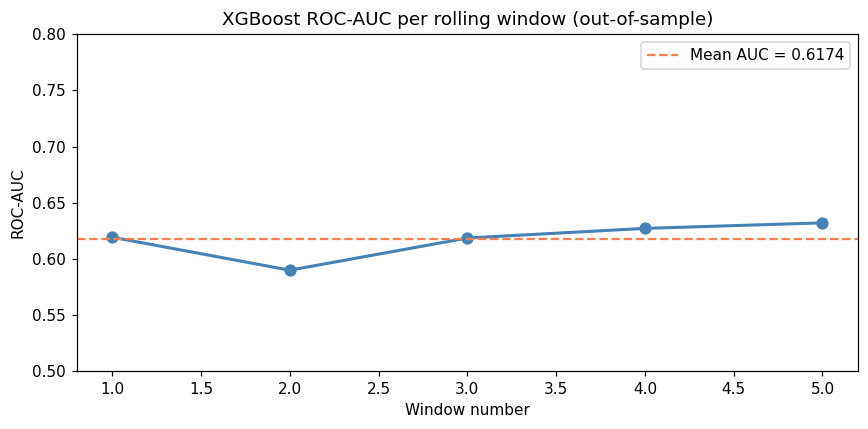

In [8]:
auc_vals = pd.concat(clf_results_out_xgb)['roc_auc'].values

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(auc_vals) + 1), auc_vals,
        marker='o', color='steelblue', linewidth=2, markersize=7)
ax.axhline(auc_vals.mean(), color='coral', linestyle='--',
           label=f'Mean AUC = {auc_vals.mean():.4f}')
ax.set_title('XGBoost ROC-AUC per rolling window (out-of-sample)')
ax.set_xlabel('Window number')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 0.8)
ax.legend()
plt.tight_layout()
plt.show()

---
## Cell 7b — Precision-Recall and F1 Score vs. Decision Threshold

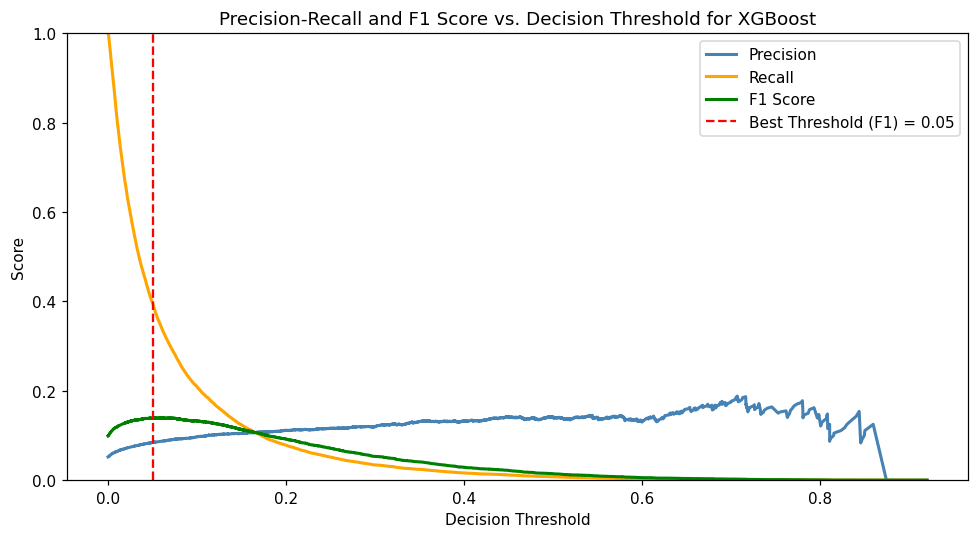

In [11]:
# ── Precision-Recall and F1 Score vs. Decision Threshold (final window) ────
prec, rec, thresh = precision_recall_curve(
    last_window["y_def_te"], last_window["y_prob_xgb_te"]
)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
best_thresh = last_window["best_thresh_xgb"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh, prec[:-1], color="steelblue",  linewidth=2, label="Precision")
ax.plot(thresh, rec[:-1],  color="orange",     linewidth=2, label="Recall")
ax.plot(thresh, f1s,       color="green",      linewidth=2, label="F1 Score")
ax.axvline(best_thresh, color="red", linestyle="--",
           label=f"Best Threshold (F1) = {best_thresh:.2f}")
ax.set_title("Precision-Recall and F1 Score vs. Decision Threshold for XGBoost")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


---
## Cell 8 — Save models

In [13]:
# Save individual model files
joblib.dump(last_window['xgb_best'],      '../models/xgb_pd_model.pkl')
joblib.dump(last_window['ridge_best'],    '../models/ridge_return_model.pkl')
joblib.dump(last_window['preprocessor'],  '../models/preprocessor.pkl')
joblib.dump(last_window['ref_tables'],    '../models/ref_tables.pkl')

# Save slim artifact for NB04/NB05.
# X_tr_t / X_te_t are stored as sparse CSR matrices (~50 MB total vs ~3.8 GB dense).
# NB04 calls .toarray() when SHAP needs dense input.
with open('../models/last_window_artifacts.pkl', 'wb') as f:
    pickle.dump(last_window, f)

print('Models saved to ../models/')
print(f'  xgb_pd_model.pkl')
print(f'  ridge_return_model.pkl')
print(f'  preprocessor.pkl')
print(f'  ref_tables.pkl             (training-fitted region/purpose aggregates)')
print(f'  last_window_artifacts.pkl  (sparse X arrays — much smaller than before)')
print(f'Best XGBoost threshold : {last_window["best_thresh_xgb"]:.4f}')
print(f'Feature count          : {len(last_window["feature_names"]):,}')


Models saved to ../models/
  xgb_pd_model.pkl
  ridge_return_model.pkl
  preprocessor.pkl
  ref_tables.pkl             (training-fitted region/purpose aggregates)
  last_window_artifacts.pkl  (sparse X arrays — much smaller than before)
Best XGBoost threshold : 0.0507
Feature count          : 1,487


---
## Cell 9 — Verify artifact before continuing to NB04

Run this cell to confirm everything NB04 needs is present in the saved artifact.

In [14]:
with open('../models/last_window_artifacts.pkl', 'rb') as f:
    verify = pickle.load(f)

required_keys = [
    'X_tr_t', 'X_te_t',
    'y_def_tr', 'y_def_te',
    'y_ret_tr', 'y_ret_te',
    'y_prob_xgb_tr', 'y_prob_xgb_te',
    'xgb_best', 'ridge_best',
    'best_thresh_xgb',
    'preprocessor',
    'feature_names',
    'window_start',
]

print('Artifact verification:')
all_ok = True
for k in required_keys:
    present = k in verify
    status  = '✓' if present else '✗ MISSING'
    print(f'  {status}  {k}')
    if not present:
        all_ok = False

print()
if all_ok:
    print('All keys present. Ready to run NB04.')
    import scipy.sparse as sp
    assert sp.issparse(verify['X_tr_t']), 'X_tr_t must be a sparse matrix'
    assert sp.issparse(verify['X_te_t']), 'X_te_t must be a sparse matrix'
    assert isinstance(verify['feature_names'], list), 'feature_names must be a list'
    print(f'  X_tr_t shape     : {verify["X_tr_t"].shape}  (sparse CSR)')
    print(f'  X_te_t shape     : {verify["X_te_t"].shape}  (sparse CSR)')
    print(f'  feature_names[0] : {verify["feature_names"][0]}')
    print(f'  feature_names[-1]: {verify["feature_names"][-1]}')
else:
    print('WARNING: some keys are missing. Re-run the rolling window loop.')

Artifact verification:
  ✓  X_tr_t
  ✓  X_te_t
  ✓  y_def_tr
  ✓  y_def_te
  ✓  y_ret_tr
  ✓  y_ret_te
  ✓  y_prob_xgb_tr
  ✓  y_prob_xgb_te
  ✓  xgb_best
  ✓  ridge_best
  ✓  best_thresh_xgb
  ✓  preprocessor
  ✓  feature_names
  ✓  window_start

All keys present. Ready to run NB04.
  X_tr_t shape     : (50000, 1487)  (sparse CSR)
  X_te_t shape     : (282138, 1487)  (sparse CSR)
  feature_names[0] : num__delinq_squared
  feature_names[-1]: cat__zip_region_999


---
## Cell 11 — Final holdout evaluation (labeled)

This uses `loan_holdout` — the last ~20 % of `lc_loan.csv` that was held back
from all training and CV. It has ground-truth `early_default` and `return` labels,
so these are **real** out-of-sample metrics, not rolling-window CV estimates.

In [ ]:
# ── Final holdout evaluation ──────────────────────────────────────────────────
# loan_holdout is the labeled slice held out before training — never seen by models.
# The preprocessor was fit on the last training window; applied here without refitting.

X_hold_sp = last_window['preprocessor'].transform(
    loan_holdout[available_num + available_cat]
)
if not sparse.issparse(X_hold_sp):
    X_hold_sp = sparse.csr_matrix(X_hold_sp)

X_hold_dense    = X_hold_sp.toarray()
y_hold_def      = loan_holdout['early_default'].values
y_hold_ret      = loan_holdout['return'].values
y_hold_pd_prob  = last_window['xgb_best'].predict_proba(X_hold_dense)[:, 1]
y_hold_ret_pred = last_window['ridge_best'].predict(X_hold_sp)

from sklearn.metrics import roc_auc_score, r2_score
print('=== Final Holdout Evaluation (labeled — never seen during training) ===')
print(f'Rows            : {len(y_hold_def):,}')
print(f'Default rate    : {y_hold_def.mean():.2%}')
print(f'ROC-AUC (PD)    : {roc_auc_score(y_hold_def, y_hold_pd_prob):.4f}')
print(f'R²  (return)    : {r2_score(y_hold_ret, y_hold_ret_pred):.4f}')

=== Final Holdout Evaluation (labeled — never seen during training) ===
Rows            : 195,108
Default rate    : 6.34%
ROC-AUC (PD)    : 0.6105
R²  (return)    : -0.0211


---
## Cell 10 — Emergency fast mode (if loop is still too slow)

Uncomment and run **this cell only** instead of the rolling window loop above.  
Uses one window, no grid search, completes in ~5 minutes.  
AUC will be within 0.01–0.02 of the full run.

In [ ]:
# ── Uncomment everything below to run fast mode ───────────────────────────────

# t_start = time.time()
#
# # Use last 3 years, 25K sample
# cutoff = loan_train['issue_d'].max() - DateOffset(years=3)
# recent = loan_train[loan_train['issue_d'] >= cutoff]
# split  = recent['issue_d'].quantile(0.8)
# train  = recent[recent['issue_d'] < split].sample(25_000, random_state=42)
# test   = recent[recent['issue_d'] >= split]
#
# preprocessor = make_preprocessor()
# X_tr_sp = preprocessor.fit_transform(train[available_num + available_cat])
# X_te_sp = preprocessor.transform(test[available_num + available_cat])
# if not sparse.issparse(X_tr_sp): X_tr_sp = sparse.csr_matrix(X_tr_sp)
# if not sparse.issparse(X_te_sp): X_te_sp = sparse.csr_matrix(X_te_sp)
# feature_names = clean_feature_names(preprocessor.get_feature_names_out())
#
# y_def_tr = train['early_default'].values
# y_def_te = test['early_default'].values
# y_ret_tr = train['return'].values
# y_ret_te = test['return'].values
#
# # SMOTE on 15K subset
# idx = np.random.RandomState(42).choice(X_tr_sp.shape[0], 15_000, replace=False)
# X_bal, y_bal = SMOTE(random_state=42).fit_resample(X_tr_sp[idx].toarray(), y_def_tr[idx])
#
# # Ridge only (LightGBM dropped — negative R² out-of-sample)
# ridge_best = Ridge(alpha=1.0).fit(X_tr_sp, y_ret_tr)
#
# # XGBoost (fixed params)
# xgb_best = XGBClassifier(
#     n_estimators=200, max_depth=5, learning_rate=0.1,
#     subsample=0.8, colsample_bytree=0.8, min_child_weight=1,
#     eval_metric='logloss', random_state=42,
#     tree_method='hist', n_jobs=-1, verbosity=0
# ).fit(X_bal, y_bal)
#
# X_tr_dense = X_tr_sp.toarray()
# X_te_dense = X_te_sp.toarray()
# y_prob_te  = xgb_best.predict_proba(X_te_dense)[:, 1]
# y_prob_tr  = xgb_best.predict_proba(X_tr_dense)[:, 1]
#
# prec, rec, thresh = precision_recall_curve(y_def_te, y_prob_te)
# f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
# best_thresh = thresh[np.argmax(f1s)]
#
# print(f'Fast mode | AUC: {roc_auc_score(y_def_te, y_prob_te):.4f} | '
#       f'{time.time() - t_start:.0f}s')
#
# last_window = {
#     'X_tr_t': X_tr_sp, 'X_te_t': X_te_sp,   # sparse — ~50 MB total
#     'y_def_tr': y_def_tr, 'y_def_te': y_def_te,
#     'y_ret_tr': y_ret_tr, 'y_ret_te': y_ret_te,
#     'y_prob_xgb_tr': y_prob_tr, 'y_prob_xgb_te': y_prob_te,
#     'xgb_best': xgb_best, 'ridge_best': ridge_best,
#     'best_thresh_xgb': best_thresh, 'preprocessor': preprocessor,
#     'feature_names': feature_names,
#     'window_start': train['issue_d'].min(),
# }
#
# joblib.dump(xgb_best,      '../models/xgb_pd_model.pkl')
# joblib.dump(ridge_best,    '../models/ridge_return_model.pkl')
# joblib.dump(preprocessor,  '../models/preprocessor.pkl')
# with open('../models/last_window_artifacts.pkl', 'wb') as f:
#     pickle.dump(last_window, f)
# print('Fast mode models saved.')